# Pneumonia Detection from Chest X-Rays — VGG16 Transfer Learning

Binary classification (**NORMAL** vs **PNEUMONIA**) using a VGG16 backbone pretrained on ImageNet, fine-tuned on the
[Kaggle Chest X-Ray Images (Pneumonia) dataset](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia).

**Pipeline:**
1. Download & inspect data
2. Data generators with augmentation
3. Build VGG16 feature extractor + custom classification head (frozen base)
4. Train the head
5. Fine-tune the top VGG16 conv block
6. Evaluate: accuracy, precision/recall, confusion matrix, ROC-AUC
7. Save the model

Runtime: **Colab, GPU** (`Runtime > Change runtime type > T4 GPU`).


## 1. Setup


In [ ]:
!pip install -q kaggle kagglehub


In [ ]:
import os, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download the dataset

Uses `kagglehub` (no manual `kaggle.json` upload needed in most Colab sessions; if it prompts for auth,
upload your Kaggle API token when asked, or use the alternative `kaggle.json` cell below it).


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print('Dataset downloaded to:', dataset_path)

# The Kaggle archive nests everything under chest_xray/chest_xray — normalise that here.
base_dir_candidates = [
    os.path.join(dataset_path, 'chest_xray', 'chest_xray'),
    os.path.join(dataset_path, 'chest_xray'),
]
BASE_DIR = next(p for p in base_dir_candidates if os.path.isdir(p))
print('Using BASE_DIR:', BASE_DIR)
print(os.listdir(BASE_DIR))


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia
Using BASE_DIR: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
['val', '.DS_Store', 'test', 'train']


In [ ]:
# --- Alternative manual download (skip if kagglehub cell above worked) ---
# from google.colab import files
# files.upload()  # upload your kaggle.json here
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data --unzip
# BASE_DIR = '/content/data/chest_xray'


## 3. Inspect class balance


In [ ]:
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    for cls in ['NORMAL', 'PNEUMONIA']:
        p = os.path.join(d, cls)
        n = len(os.listdir(p)) if os.path.isdir(p) else 0
        print(f'{split:6s} | {cls:10s} | {n} images')



train  | NORMAL     | 1342 images
train  | PNEUMONIA  | 3876 images
val    | NORMAL     | 9 images
val    | PNEUMONIA  | 9 images
test   | NORMAL     | 234 images
test   | PNEUMONIA  | 390 images


The official Kaggle split has a **tiny `val` folder (16 images)**, which is unreliable for model selection.
We rebuild the split: merge `train` + `val`, then carve out a proper stratified validation set (~15%) ourselves,
keeping the original `test` folder untouched as the true held-out set.


In [ ]:
import glob
from sklearn.model_selection import train_test_split

def list_files(d):
    normal = glob.glob(os.path.join(d, 'NORMAL', '*.jpeg')) + glob.glob(os.path.join(d, 'NORMAL', '*.jpg'))
    pneumonia = glob.glob(os.path.join(d, 'PNEUMONIA', '*.jpeg')) + glob.glob(os.path.join(d, 'PNEUMONIA', '*.jpg'))
    return normal, pneumonia

train_normal, train_pneu = list_files(TRAIN_DIR)
val_normal, val_pneu = list_files(VAL_DIR)

all_normal = train_normal + val_normal
all_pneu = train_pneu + val_pneu

files = all_normal + all_pneu
labels = [0]*len(all_normal) + [1]*len(all_pneu)   # 0 = NORMAL, 1 = PNEUMONIA

train_files, val_files, train_labels, val_labels = train_test_split(
    files, labels, test_size=0.15, stratify=labels, random_state=SEED)

print('New train size:', len(train_files), '| New val size:', len(val_files))


New train size: 4447 | New val size: 785


In [ ]:
# Materialise the rebuilt split into a working directory Keras' flow_from_directory can read
WORK_DIR = '/content/data_split'
for split in ['train', 'val']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(os.path.join(WORK_DIR, split, cls), exist_ok=True)

def materialise(file_list, label_list, split):
    for f, lbl in zip(file_list, label_list):
        cls = 'PNEUMONIA' if lbl == 1 else 'NORMAL'
        dst = os.path.join(WORK_DIR, split, cls, os.path.basename(f))
        if not os.path.exists(dst):
            os.symlink(f, dst)

materialise(train_files, train_labels, 'train')
materialise(val_files, val_labels, 'val')

print('train/NORMAL   :', len(os.listdir(os.path.join(WORK_DIR, 'train', 'NORMAL'))))
print('train/PNEUMONIA:', len(os.listdir(os.path.join(WORK_DIR, 'train', 'PNEUMONIA'))))
print('val/NORMAL     :', len(os.listdir(os.path.join(WORK_DIR, 'val', 'NORMAL'))))
print('val/PNEUMONIA  :', len(os.listdir(os.path.join(WORK_DIR, 'val', 'PNEUMONIA'))))


train/NORMAL   : 1147
train/PNEUMONIA: 3300
val/NORMAL     : 202
val/PNEUMONIA  : 583


In [ ]:
# Class imbalance is significant (far more PNEUMONIA than NORMAL) -> compute class weights
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=train_labels)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print('Class weights:', class_weight)


Class weights: {0: np.float64(1.9385353095030515), 1: np.float64(0.6737878787878788)}


## 4. Preview sample images


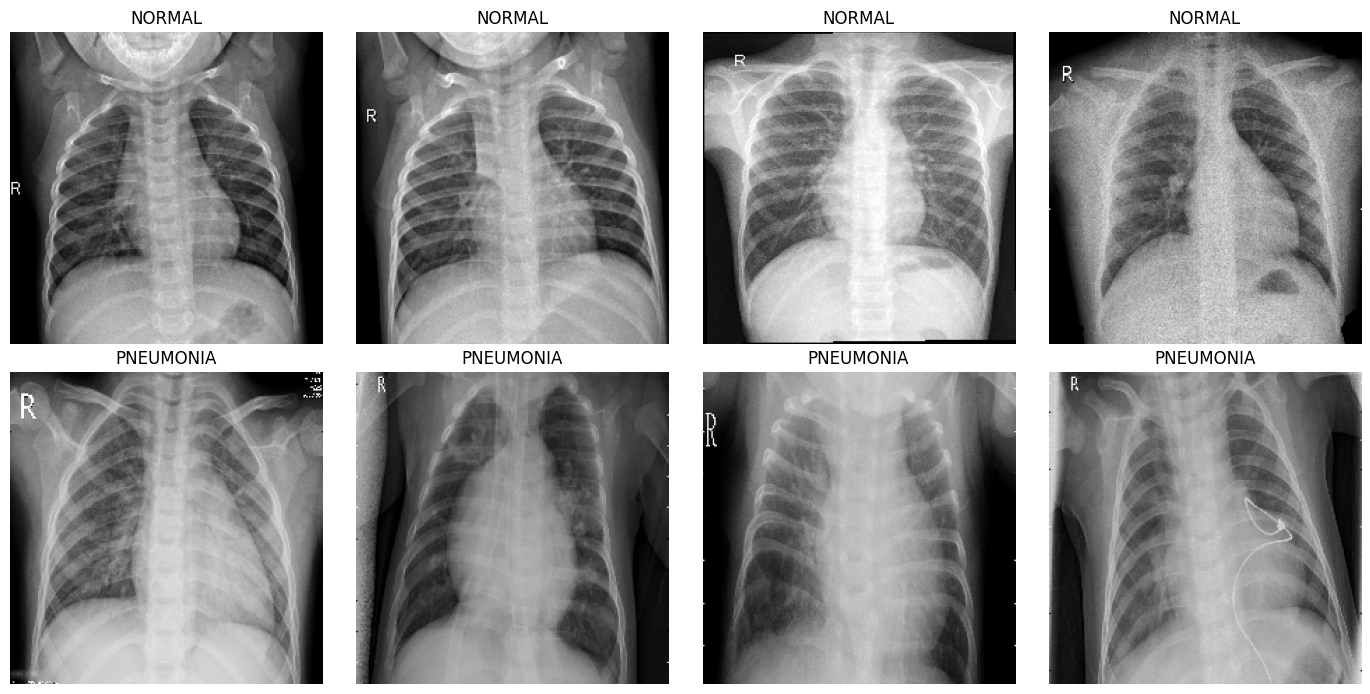

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    sample_files = os.listdir(os.path.join(WORK_DIR, 'train', cls))[:4]
    for j, fname in enumerate(sample_files):
        img = tf.keras.utils.load_img(os.path.join(WORK_DIR, 'train', cls, fname), target_size=(224, 224))
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(cls)
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()


## 5. Data generators


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=['NORMAL', 'PNEUMONIA'], seed=SEED)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'val'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=['NORMAL', 'PNEUMONIA'], shuffle=False, seed=SEED)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=['NORMAL', 'PNEUMONIA'], shuffle=False, seed=SEED)

print('Class indices:', train_gen.class_indices)


Found 4447 images belonging to 2 classes.
Found 785 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## 6. Build the model

VGG16 convolutional base (ImageNet weights, no top) + a custom binary classification head.
The base is frozen first so only the new head learns, avoiding destroying the pretrained filters early on.


In [ ]:
def build_model(fine_tune_at=None):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    if fine_tune_at is not None:
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

model, base_model = build_model()
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,44

 Total params: 14,864,577 (56.70 MB)

 Trainable params: 148,865 (581.50 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

## 7. Compile & train the classification head (base frozen)


In [ ]:
METRICS = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
]

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=METRICS)

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ModelCheckpoint('vgg16_pneumonia_head.keras', monitor='val_auc', mode='max', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
]

EPOCHS_HEAD = 2

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight,
    callbacks=callbacks
)


Epoch 1/2
139/139 ━━━━━━━━━━━━━━━━━━━━ 135s 928ms/step - accuracy: 0.8658 - auc: 0.9422 - loss: 0.3084 - precision: 0.9549 - recall: 0.8597 - val_accuracy: 0.8637 - val_auc: 0.9821 - val_loss: 0.3714 - val_precision: 0.9979 - val_recall: 0.8182 - learning_rate: 1.0000e-04
Epoch 2/2
139/139 ━━━━━━━━━━━━━━━━━━━━ 116s 832ms/step - accuracy: 0.8930 - auc: 0.9572 - loss: 0.2642 - precision: 0.9648 - recall: 0.8882 - val_accuracy: 0.8777 - val_auc: 0.9847 - val_loss: 0.3322 - val_precision: 0.9980 - val_recall: 0.8370 - learning_rate: 1.0000e-04


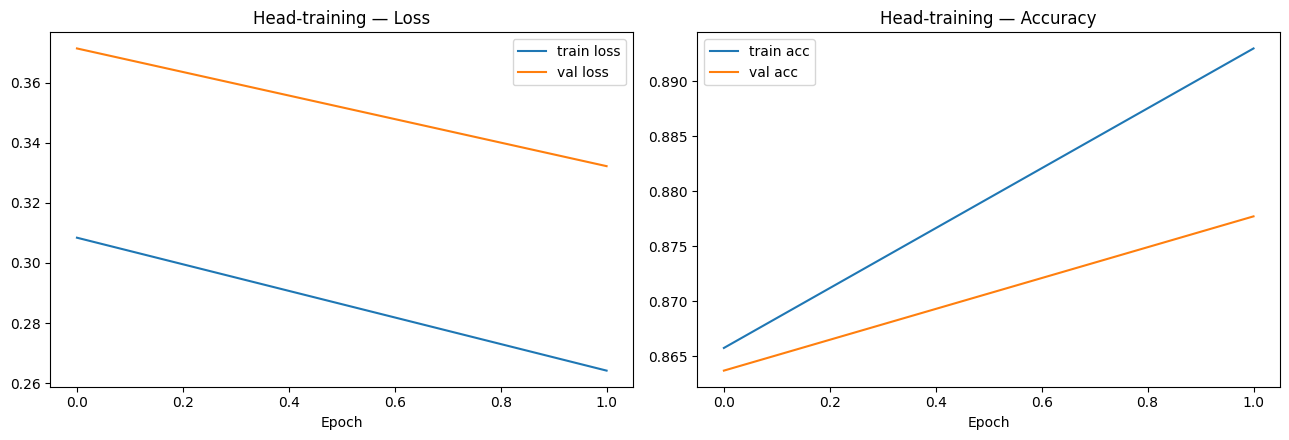

In [ ]:
def plot_history(history, title_prefix=''):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(hist['loss'], label='train loss')
    axes[0].plot(hist['val_loss'], label='val loss')
    axes[0].set_title(f'{title_prefix}Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(hist['accuracy'], label='train acc')
    axes[1].plot(hist['val_accuracy'], label='val acc')
    axes[1].set_title(f'{title_prefix}Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history_head, 'Head-training — ')


## 8. Fine-tune the top VGG16 block

Unfreeze the last convolutional block (`block5`) and continue training with a much smaller learning rate,
so the pretrained ImageNet filters adapt to X-ray textures without being wrecked by large gradient updates.


In [ ]:
# VGG16 has 19 layers; block5 starts at layer index 15 (block5_conv1)
FINE_TUNE_AT = 15

model, base_model = build_model(fine_tune_at=FINE_TUNE_AT)
model.load_weights('vgg16_pneumonia_head.keras')

model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=METRICS)

callbacks_ft = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ModelCheckpoint('vgg16_pneumonia_finetuned.keras', monitor='val_auc', mode='max', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8),
]

EPOCHS_FT = 2

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT,
    class_weight=class_weight,
    callbacks=callbacks_ft
)


Epoch 1/2
139/139 ━━━━━━━━━━━━━━━━━━━━ 138s 941ms/step - accuracy: 0.9043 - auc: 0.9712 - loss: 0.2019 - precision: 0.9755 - recall: 0.8937 - val_accuracy: 0.8955 - val_auc: 0.9900 - val_loss: 0.3169 - val_precision: 1.0000 - val_recall: 0.8593 - learning_rate: 1.0000e-05
Epoch 2/2
139/139 ━━━━━━━━━━━━━━━━━━━━ 119s 855ms/step - accuracy: 0.9460 - auc: 0.9867 - loss: 0.1428 - precision: 0.9873 - recall: 0.9394 - val_accuracy: 0.9172 - val_auc: 0.9917 - val_loss: 0.2557 - val_precision: 1.0000 - val_recall: 0.8885 - learning_rate: 1.0000e-05


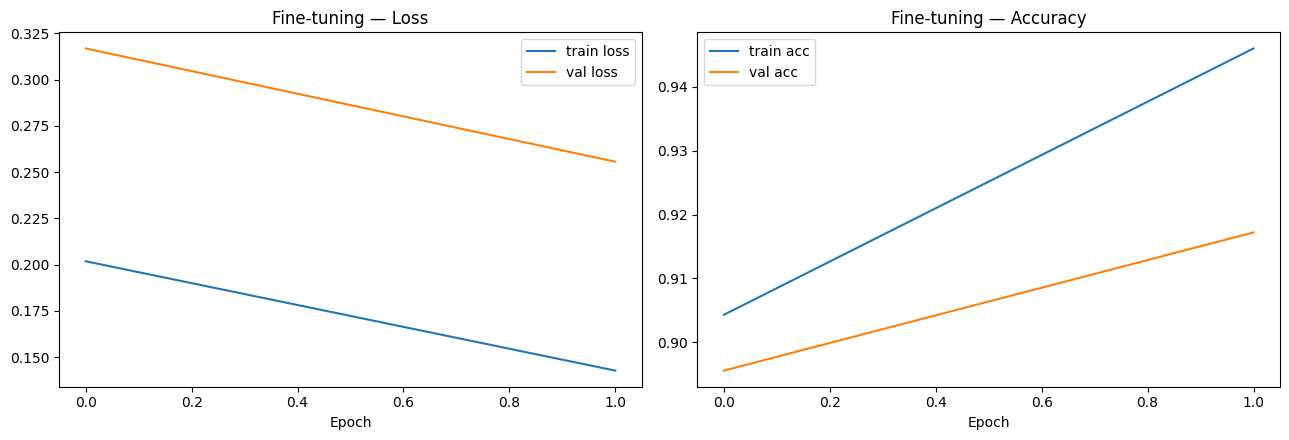

In [ ]:
plot_history(history_ft, 'Fine-tuning — ')


## 9. Evaluate on the held-out test set


In [ ]:
test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(test_gen)
print(f'Test accuracy : {test_acc:.4f}')
print(f'Test AUC      : {test_auc:.4f}')
print(f'Test precision: {test_prec:.4f}')
print(f'Test recall   : {test_rec:.4f}')


20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 924ms/step - accuracy: 0.9199 - auc: 0.9731 - loss: 0.2054 - precision: 0.9208 - recall: 0.9538
Test accuracy : 0.9199
Test AUC      : 0.9731
Test precision: 0.9208
Test recall   : 0.9538


In [ ]:
y_true = test_gen.classes
y_prob = model.predict(test_gen).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step
              precision    recall  f1-score   support

      NORMAL       0.92      0.86      0.89       234
   PNEUMONIA       0.92      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



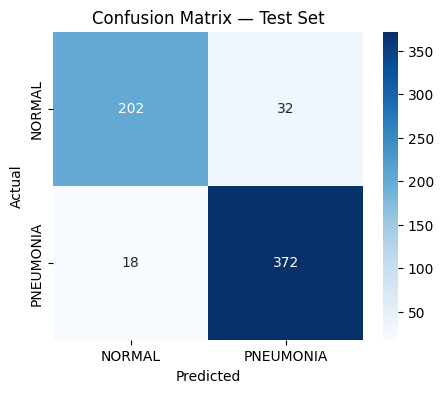

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix — Test Set')
plt.show()


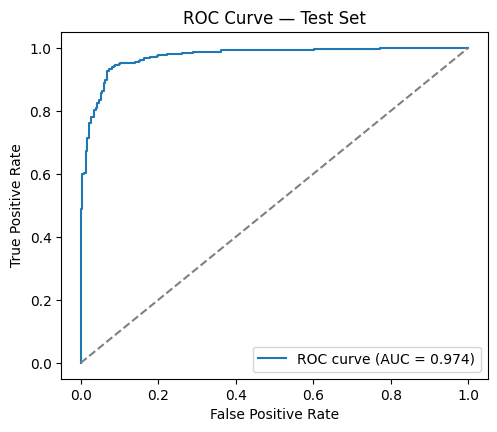

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set'); plt.legend()
plt.show()


## 10. Threshold tuning (optional)

For a medical screening task, missing a true pneumonia case (false negative) is usually worse than a false alarm.
Lowering the decision threshold below 0.5 trades some precision for higher recall — inspect the precision/recall
curve and pick a threshold that fits the clinical tolerance you're designing for.


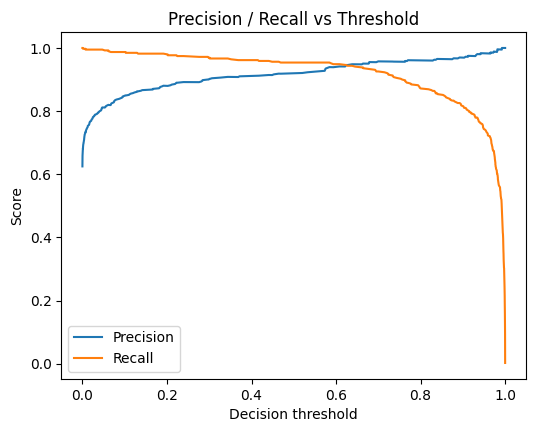

Threshold for recall >= 0.95: 0.584  (precision=0.939, recall=0.954)


In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6, 4.5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Decision threshold'); plt.ylabel('Score')
plt.title('Precision / Recall vs Threshold'); plt.legend()
plt.show()

# Example: force recall >= 0.95 for PNEUMONIA class
target_recall = 0.95
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precisions[:-1][valid_idx])]
    print(f'Threshold for recall >= {target_recall}: {thresholds[best_idx]:.3f} ',
          f'(precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f})')


## 11. Save the final model


In [ ]:
model.save('vgg16_pneumonia_final.keras')
print('Saved model to vgg16_pneumonia_final.keras')

# Optional: download from Colab
# from google.colab import files
# files.download('vgg16_pneumonia_final.keras')


Saved model to vgg16_pneumonia_final.keras


## 12. Predict on a single new image


In [ ]:
def predict_single_image(img_path, threshold=0.5):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    arr = tf.keras.utils.img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)
    prob = model.predict(arr, verbose=0)[0][0]
    label = 'PNEUMONIA' if prob >= threshold else 'NORMAL'
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{label}  (p={prob:.3f})')
    plt.show()
    return label, prob

# Example usage:
# predict_single_image(os.path.join(TEST_DIR, 'PNEUMONIA', os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA'))[0]))


## Notes
- **Class imbalance** is handled via `class_weight`, not oversampling — keeps augmentation/training simple while still penalising the majority class less.
- The official `val` split (16 images) was too small for reliable model selection, so it's merged into `train` and a fresh stratified validation split is carved out; `test` is left untouched as the true held-out evaluation set.
- Two-stage training (frozen head → fine-tune `block5`) avoids catastrophic forgetting of ImageNet features early on.
- For a clinical-style deployment, prefer the **recall-oriented threshold** from Section 10 over the default 0.5 — false negatives (missed pneumonia) are costlier than false positives here.
- Swap `VGG16` for `VGG19`/`ResNet50`/`DenseNet121` by changing one import + one line if you want to compare backbones.
